# Part B

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, LSTM, GRU, Flatten, Dropout,
                                     Conv1D, MaxPooling1D, GlobalAveragePooling1D,
                                     Input, MultiHeadAttention, LayerNormalization,
                                     Add)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

## Load & Basic EDA

In [2]:
df = pd.read_csv("AUD-CAD_Second_2022-04-25_12h-18h_UTC.csv")

df["UTC"] = pd.to_datetime(df["UTC"])
df = df.sort_values("UTC").reset_index(drop=True)
df = df.dropna()

print("Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nStatistical summary:")
print(df.describe().round(6))

Shape: (21042, 6)

First few rows:
                        UTC     Open     High      Low    Close  Volume
0 2022-04-25 12:00:00+00:00  0.91557  0.91557  0.91550  0.91550   13.82
1 2022-04-25 12:00:01+00:00  0.91550  0.91553  0.91546  0.91547   14.26
2 2022-04-25 12:00:02+00:00  0.91546  0.91547  0.91546  0.91547    3.60
3 2022-04-25 12:00:03+00:00  0.91545  0.91545  0.91545  0.91545    2.70
4 2022-04-25 12:00:05+00:00  0.91550  0.91550  0.91548  0.91549    4.34

Data types:
UTC       datetime64[ns, UTC]
Open                  float64
High                  float64
Low                   float64
Close                 float64
Volume                float64
dtype: object

Statistical summary:
               Open          High           Low         Close        Volume
count  21042.000000  21042.000000  21042.000000  21042.000000  21042.000000
mean       0.913535      0.913545      0.913525      0.913535      4.364720
std        0.001080      0.001079      0.001081      0.001080      2.801477


## Distribution & Correlation Visualisations

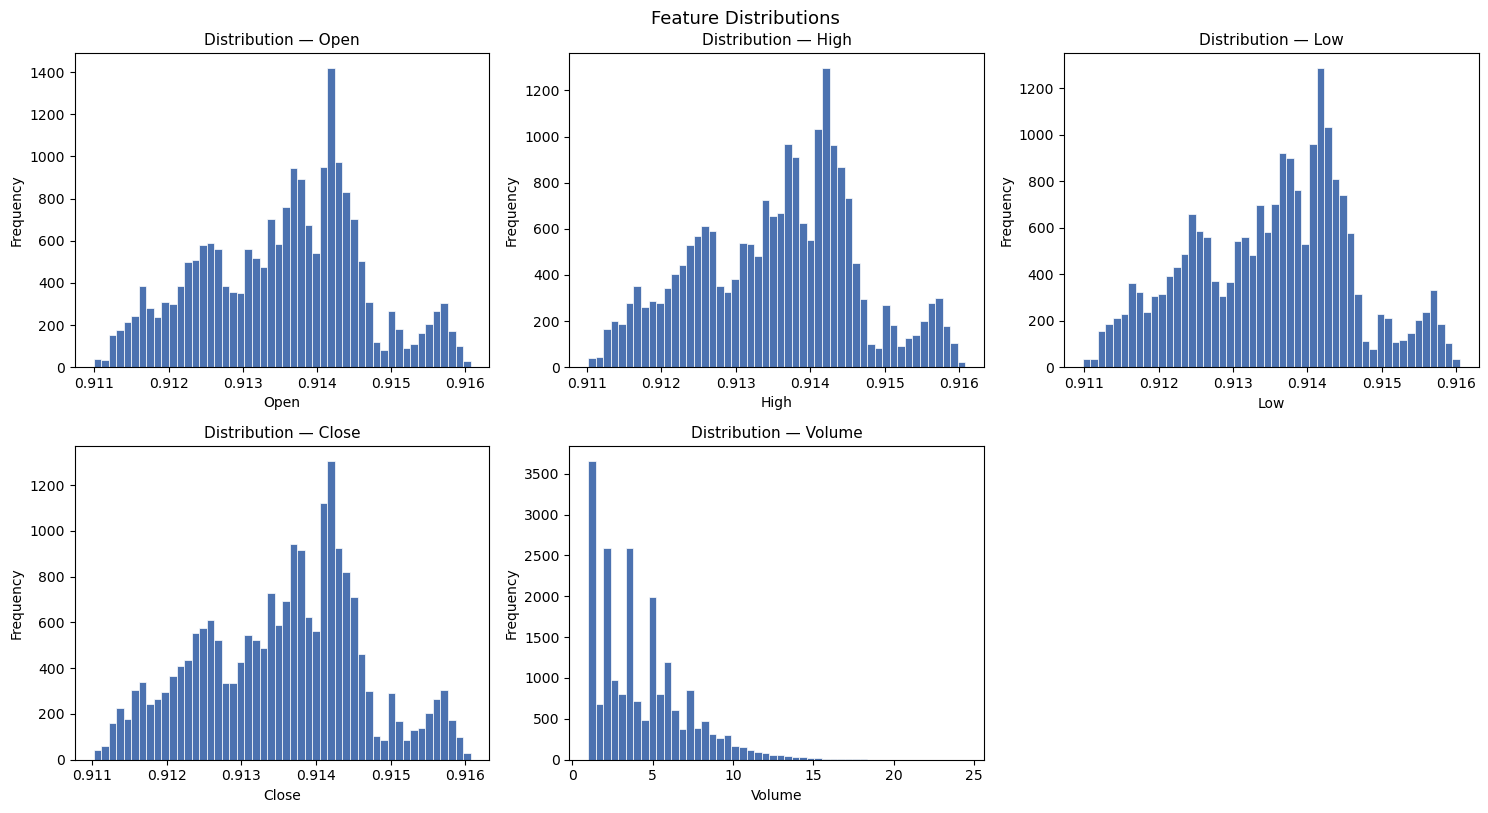

In [4]:
features = ["Open", "High", "Low", "Close", "Volume"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=50, color="#4C72B0", edgecolor="white", linewidth=0.5)
    axes[i].set_title(f"Distribution — {col}", fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

axes[5].set_visible(False)
plt.tight_layout()
plt.suptitle("Feature Distributions", fontsize=13, y=1.01)
plt.savefig("partB_dist.png", dpi=150, bbox_inches="tight")
plt.show()

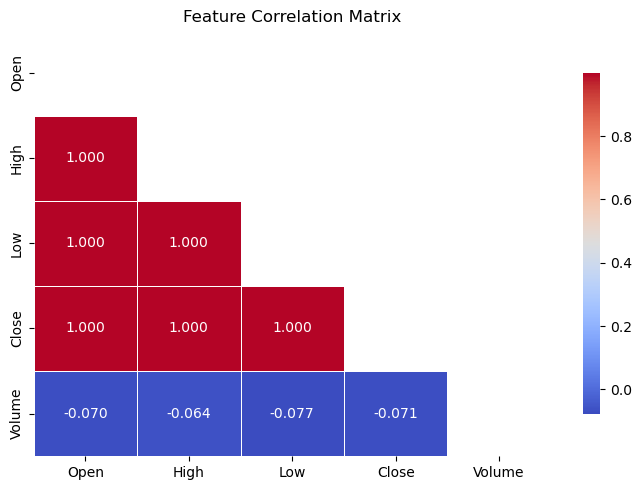

In [5]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(7, 5))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm",
            mask=mask, ax=ax, linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Matrix", fontsize=12)
plt.tight_layout()
plt.savefig("partB_corr.png", dpi=150, bbox_inches="tight")
plt.show()

## Technical Indicators

In [6]:
# Moving Averages
df["MA_5"]  = df["Close"].rolling(5).mean()
df["MA_10"] = df["Close"].rolling(10).mean()
df["MA_20"] = df["Close"].rolling(20).mean()

# Exponential Moving Average
df["EMA_10"] = df["Close"].ewm(span=10, adjust=False).mean()

df["BB_mid"]   = df["Close"].rolling(20).mean()
df["BB_std"]   = df["Close"].rolling(20).std()
df["BB_upper"] = df["BB_mid"] + 2 * df["BB_std"]
df["BB_lower"] = df["BB_mid"] - 2 * df["BB_std"]

delta = df["Close"].diff()
gain  = delta.clip(lower=0)
loss  = -delta.clip(upper=0)
avg_gain = gain.ewm(com=13, adjust=False).mean()
avg_loss = loss.ewm(com=13, adjust=False).mean()
rs = avg_gain / (avg_loss + 1e-10)
df["RSI_14"] = 100 - (100 / (1 + rs))

# MACD 
ema_12 = df["Close"].ewm(span=12, adjust=False).mean()
ema_26 = df["Close"].ewm(span=26, adjust=False).mean()
df["MACD"]        = ema_12 - ema_26
df["MACD_signal"] = df["MACD"].ewm(span=9, adjust=False).mean()
df["MACD_hist"]   = df["MACD"] - df["MACD_signal"]

high_low   = df["High"] - df["Low"]
high_close = (df["High"] - df["Close"].shift()).abs()
low_close  = (df["Low"]  - df["Close"].shift()).abs()
tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
df["ATR_14"] = tr.ewm(com=13, adjust=False).mean()

df["ROC_10"] = df["Close"].pct_change(10) * 100

df = df.dropna().reset_index(drop=True)
print("Shape after adding indicators:", df.shape)
print(df[["Close","MA_5","MA_20","RSI_14","MACD","ATR_14","ROC_10"]].head(10).round(6))

Shape after adding indicators: (21023, 20)
     Close      MA_5     MA_20     RSI_14      MACD    ATR_14    ROC_10
0  0.91535  0.915368  0.915380  29.165754 -0.000028  0.000048 -0.001092
1  0.91536  0.915366  0.915372  31.144584 -0.000027  0.000045  0.001092
2  0.91536  0.915360  0.915367  31.144574 -0.000025  0.000042 -0.001092
3  0.91538  0.915364  0.915362  35.334784 -0.000022  0.000040  0.000000
4  0.91539  0.915368  0.915359  37.386506 -0.000019  0.000039  0.003277
5  0.91537  0.915372  0.915353  34.994992 -0.000018  0.000038  0.002185
6  0.91536  0.915372  0.915358  33.829756 -0.000018  0.000036 -0.001092
7  0.91536  0.915372  0.915362  33.829744 -0.000017  0.000034 -0.003277
8  0.91531  0.915358  0.915361  28.354900 -0.000020  0.000037 -0.005462
9  0.91529  0.915338  0.915360  26.506995 -0.000024  0.000036 -0.008740


## Technical Indicator Visualisations

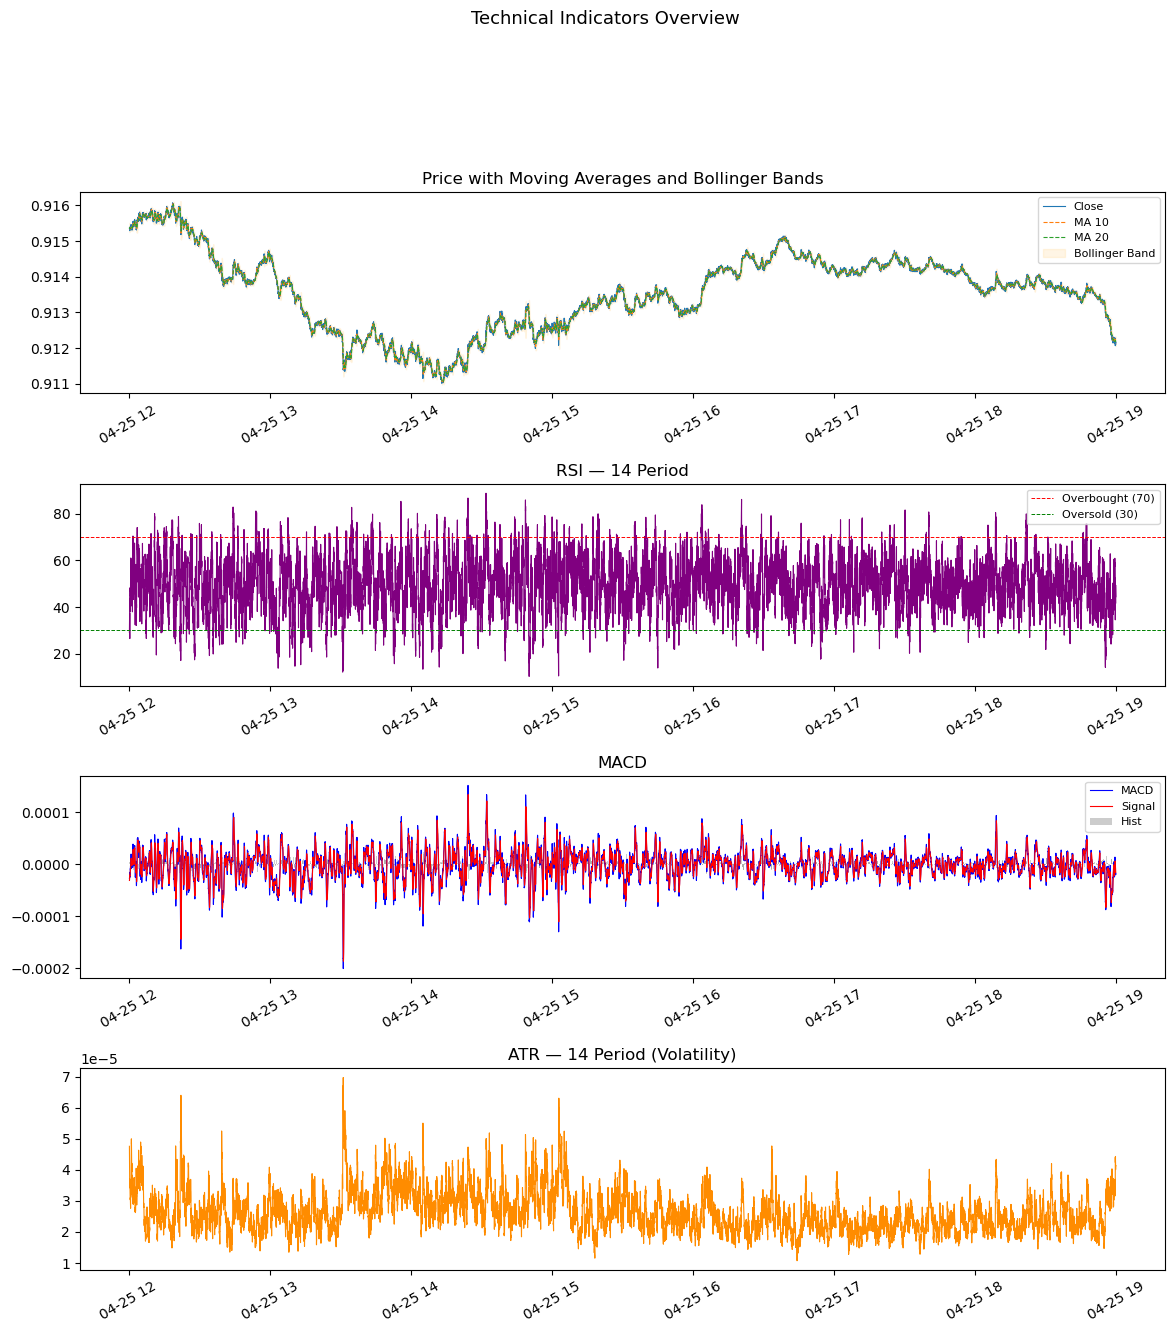

In [7]:
fig = plt.figure(figsize=(14, 14))
gs  = gridspec.GridSpec(4, 1, hspace=0.45)

ax1 = fig.add_subplot(gs[0])
ax1.plot(df["UTC"], df["Close"],    label="Close",    linewidth=0.8)
ax1.plot(df["UTC"], df["MA_10"],    label="MA 10",    linewidth=0.8, linestyle="--")
ax1.plot(df["UTC"], df["MA_20"],    label="MA 20",    linewidth=0.8, linestyle="--")
ax1.fill_between(df["UTC"], df["BB_upper"], df["BB_lower"], alpha=0.1, color="orange", label="Bollinger Band")
ax1.set_title("Price with Moving Averages and Bollinger Bands")
ax1.legend(fontsize=8)
ax1.tick_params(axis="x", rotation=30)

ax2 = fig.add_subplot(gs[1])
ax2.plot(df["UTC"], df["RSI_14"], color="purple", linewidth=0.8)
ax2.axhline(70, color="red",   linestyle="--", linewidth=0.7, label="Overbought (70)")
ax2.axhline(30, color="green", linestyle="--", linewidth=0.7, label="Oversold (30)")
ax2.set_title("RSI — 14 Period")
ax2.legend(fontsize=8)
ax2.tick_params(axis="x", rotation=30)

ax3 = fig.add_subplot(gs[2])
ax3.plot(df["UTC"], df["MACD"],        label="MACD",   color="blue",  linewidth=0.8)
ax3.plot(df["UTC"], df["MACD_signal"], label="Signal", color="red",   linewidth=0.8)
ax3.bar(df["UTC"],  df["MACD_hist"],   label="Hist",   color="gray",  alpha=0.4, width=0.00002)
ax3.set_title("MACD")
ax3.legend(fontsize=8)
ax3.tick_params(axis="x", rotation=30)

ax4 = fig.add_subplot(gs[3])
ax4.plot(df["UTC"], df["ATR_14"], color="darkorange", linewidth=0.8)
ax4.set_title("ATR — 14 Period (Volatility)")
ax4.tick_params(axis="x", rotation=30)

plt.suptitle("Technical Indicators Overview", fontsize=13, y=1.01)
plt.savefig("partB_indicators.png", dpi=150, bbox_inches="tight")
plt.show()

## Feature Set & Preprocessing

In [8]:
indicator_cols = [
    "Open", "High", "Low", "Close", "Volume",
    "MA_5", "MA_10", "MA_20", "EMA_10",
    "BB_upper", "BB_lower",
    "RSI_14", "MACD", "MACD_signal", "MACD_hist",
    "ATR_14", "ROC_10"
]

data = df[indicator_cols].copy()

scaler = MinMaxScaler()
scaled = scaler.fit_transform(data)
scaled_df = pd.DataFrame(scaled, columns=indicator_cols)

close_idx = indicator_cols.index("Close")

n_features = len(indicator_cols)
seq_len    = 20

def create_sequences(arr, seq_len):
    X, y = [], []
    for i in range(len(arr) - seq_len):
        X.append(arr[i : i + seq_len])
        y.append(arr[i + seq_len, close_idx])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_df.values, seq_len)
print("X shape:", X.shape, "  y shape:", y.shape)

split    = int(0.8 * len(X))
X_train  = X[:split];  X_test  = X[split:]
y_train  = y[:split];  y_test  = y[split:]

print(f"Train samples: {len(X_train)}   Test samples: {len(X_test)}")

X shape: (21003, 20, 17)   y shape: (21003,)
Train samples: 16802   Test samples: 4201


## Common Callbacks

In [9]:
def get_callbacks():
    es  = EarlyStopping(monitor="val_loss", patience=8,
                        restore_best_weights=True, verbose=1)
    rlr = ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                            patience=4, min_lr=1e-6, verbose=1)
    return [es, rlr]

## Model 1: Dense (MLP Baseline)

In [10]:
model_dense = Sequential([
    Flatten(input_shape=(seq_len, n_features)),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dropout(0.1),
    Dense(1)
], name="Dense_MLP")

model_dense.compile(optimizer=Adam(1e-3), loss="mse")
model_dense.summary()

history_dense = model_dense.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=60,
    batch_size=64,
    callbacks=get_callbacks(),
    verbose=1
)

Model: "Dense_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 340)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          43,648 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 51,969 (203.00 KB)

 Trainable params: 51,969 (203.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
263/263 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0214 - val_loss: 0.0047 - learning_rate: 0.0010
Epoch 2/60
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0039 - val_loss: 0.0072 - learning_rate: 0.0010
Epoch 3/60
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0028 - val_loss: 0.0072 - learning_rate: 0.0010
Epoch 4/60
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0024 - val_loss: 0.0081 - learning_rate: 0.0010
Epoch 5/60
259/263 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0022
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0021 - val_loss: 0.0055 - learning_rate: 0.0010
Epoch 6/60
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0017 - val_loss: 0.0056 - learning_rate: 5.0000e-04
Epoch 7/60
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0017 - val_loss: 0.0050 - learning_rate: 5.0000e-04
Epoch 8/60
263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0016 - val_loss: 0.0069 - le

## Model 2: Stacked LSTM

In [11]:
model_lstm = Sequential([
    LSTM(128, return_sequences=True, input_shape=(seq_len, n_features)),
    Dropout(0.2),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dense(16, activation="relu"),
    Dense(1)
], name="Stacked_LSTM")

model_lstm.compile(optimizer=Adam(1e-3), loss="mse")
model_lstm.summary()

history_lstm = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=60,
    batch_size=64,
    callbacks=get_callbacks(),
    verbose=1
)

Model: "Stacked_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 20, 128)             │          74,752 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 20, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 20, 64)              │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 20, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 137,121 (535.63 KB)

 Trainable params: 137,121 (535.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
263/263 ━━━━━━━━━━━━━━━━━━━━ 33s 78ms/step - loss: 0.0037 - val_loss: 6.5298e-05 - learning_rate: 0.0010
Epoch 2/60
263/263 ━━━━━━━━━━━━━━━━━━━━ 19s 72ms/step - loss: 3.5772e-04 - val_loss: 7.4087e-05 - learning_rate: 0.0010
Epoch 3/60
263/263 ━━━━━━━━━━━━━━━━━━━━ 19s 73ms/step - loss: 2.9901e-04 - val_loss: 7.1888e-05 - learning_rate: 0.0010
Epoch 4/60
263/263 ━━━━━━━━━━━━━━━━━━━━ 19s 71ms/step - loss: 2.5485e-04 - val_loss: 1.1888e-04 - learning_rate: 0.0010
Epoch 5/60
262/263 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 2.2823e-04 
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
263/263 ━━━━━━━━━━━━━━━━━━━━ 19s 74ms/step - loss: 2.2501e-04 - val_loss: 5.6254e-05 - learning_rate: 0.0010
Epoch 6/60
263/263 ━━━━━━━━━━━━━━━━━━━━ 19s 73ms/step - loss: 1.8501e-04 - val_loss: 1.4054e-04 - learning_rate: 5.0000e-04
Epoch 7/60
263/263 ━━━━━━━━━━━━━━━━━━━━ 19s 73ms/step - loss: 1.7739e-04 - val_loss: 1.0585e-04 - learning_rate: 5.0000e-04
Epoch 8/60
263/263

## Model 3: Stacked GRU

In [12]:
model_gru = Sequential([
    GRU(128, return_sequences=True, input_shape=(seq_len, n_features)),
    Dropout(0.2),
    GRU(64, return_sequences=True),
    Dropout(0.2),
    GRU(32),
    Dense(16, activation="relu"),
    Dense(1)
], name="Stacked_GRU")

model_gru.compile(optimizer=Adam(1e-3), loss="mse")
model_gru.summary()

history_gru = model_gru.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=60,
    batch_size=64,
    callbacks=get_callbacks(),
    verbose=1
)

Model: "Stacked_GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 20, 128)             │          56,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 20, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ (None, 20, 64)              │          37,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 20, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_2 (GRU)                          │ (None, 32)                  │           9,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 103,649 (404.88 KB)

 Trainable params: 103,649 (404.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
263/263 ━━━━━━━━━━━━━━━━━━━━ 30s 75ms/step - loss: 0.0034 - val_loss: 9.1783e-05 - learning_rate: 0.0010
Epoch 2/60
263/263 ━━━━━━━━━━━━━━━━━━━━ 18s 67ms/step - loss: 4.5420e-04 - val_loss: 5.6147e-05 - learning_rate: 0.0010
Epoch 3/60
263/263 ━━━━━━━━━━━━━━━━━━━━ 19s 71ms/step - loss: 3.4538e-04 - val_loss: 4.7394e-05 - learning_rate: 0.0010
Epoch 4/60
263/263 ━━━━━━━━━━━━━━━━━━━━ 18s 68ms/step - loss: 2.9220e-04 - val_loss: 1.3049e-04 - learning_rate: 0.0010
Epoch 5/60
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 2.5227e-04 
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
263/263 ━━━━━━━━━━━━━━━━━━━━ 18s 69ms/step - loss: 2.6172e-04 - val_loss: 2.0783e-04 - learning_rate: 0.0010
Epoch 6/60
263/263 ━━━━━━━━━━━━━━━━━━━━ 19s 64ms/step - loss: 1.8429e-04 - val_loss: 4.2723e-05 - learning_rate: 5.0000e-04
Epoch 7/60
263/263 ━━━━━━━━━━━━━━━━━━━━ 18s 69ms/step - loss: 1.7839e-04 - val_loss: 4.0436e-05 - learning_rate: 5.0000e-04
Epoch 8/60
263/263

## Model 4: CNN-LSTM Hybrid

In [13]:
inp     = Input(shape=(seq_len, n_features))
x       = Conv1D(64, kernel_size=3, activation="relu", padding="same")(inp)
x       = Conv1D(32, kernel_size=3, activation="relu", padding="same")(x)
x       = MaxPooling1D(pool_size=2)(x)
x       = Dropout(0.2)(x)
x       = LSTM(64, return_sequences=True)(x)
x       = Dropout(0.2)(x)
x       = LSTM(32)(x)
x       = Dense(16, activation="relu")(x)
out     = Dense(1)(x)

model_cnn_lstm = Model(inp, out, name="CNN_LSTM")
model_cnn_lstm.compile(optimizer=Adam(1e-3), loss="mse")
model_cnn_lstm.summary()

history_cnn_lstm = model_cnn_lstm.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=60,
    batch_size=64,
    callbacks=get_callbacks(),
    verbose=1
)

Model: "CNN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 20, 17)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ (None, 20, 64)              │           3,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 20, 32)              │           6,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 10, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 10, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 10, 64)              │          24,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 10, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_4 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 47,297 (184.75 KB)

 Trainable params: 47,297 (184.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
263/263 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - loss: 0.0047 - val_loss: 1.0349e-04 - learning_rate: 0.0010
Epoch 2/60
263/263 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 8.5225e-04 - val_loss: 0.0012 - learning_rate: 0.0010
Epoch 3/60
263/263 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - loss: 6.4767e-04 - val_loss: 3.5234e-04 - learning_rate: 0.0010
Epoch 4/60
263/263 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - loss: 4.9402e-04 - val_loss: 3.7975e-04 - learning_rate: 0.0010
Epoch 5/60
261/263 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 4.0996e-04
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
263/263 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - loss: 3.8611e-04 - val_loss: 9.0122e-05 - learning_rate: 0.0010
Epoch 6/60
263/263 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 2.9822e-04 - val_loss: 1.5174e-04 - learning_rate: 5.0000e-04
Epoch 7/60
263/263 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 2.9253e-04 - val_loss: 5.4617e-05 - learning_rate: 5.0000e-04
Epoch 8/60
263/263 ━━━━━━━━━━

## Model 5 (Novel): Transformer Encoder

In [14]:
# Lightweight Transformer encoder for time-series forecasting
def transformer_encoder_block(x, num_heads, ff_dim, dropout_rate=0.1):
    # Multi-Head Self-Attention
    attn_out = MultiHeadAttention(num_heads=num_heads,
                                  key_dim=x.shape[-1] // num_heads)(x, x)
    attn_out = Dropout(dropout_rate)(attn_out)
    x        = LayerNormalization(epsilon=1e-6)(Add()([x, attn_out]))

    # Feed-Forward block
    ff = Dense(ff_dim, activation="relu")(x)
    ff = Dropout(dropout_rate)(ff)
    ff = Dense(x.shape[-1])(ff)
    x  = LayerNormalization(epsilon=1e-6)(Add()([x, ff]))
    return x

inp   = Input(shape=(seq_len, n_features))

x = Dense(64)(inp)

x = transformer_encoder_block(x, num_heads=4, ff_dim=128, dropout_rate=0.1)
x = transformer_encoder_block(x, num_heads=4, ff_dim=128, dropout_rate=0.1)

x   = GlobalAveragePooling1D()(x)
x   = Dense(32, activation="relu")(x)
x   = Dropout(0.1)(x)
out = Dense(1)(x)

model_transformer = Model(inp, out, name="Transformer_Encoder")
model_transformer.compile(optimizer=Adam(5e-4), loss="mse")
model_transformer.summary()

history_transformer = model_transformer.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=60,
    batch_size=64,
    callbacks=get_callbacks(),
    verbose=1
)

Model: "Transformer_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)    │ (None, 20, 17)            │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_9 (Dense)               │ (None, 20, 64)            │           1,152 │ input_layer_4[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_head_attention          │ (None, 20, 64)            │          16,640 │ dense_9[0][0],             │
│ (MultiHeadAttention)          │                           │                 │ dense_9[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_9 (Dropout)           │ (None, 20, 64)            │               0 │ multi_head_attention[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 20, 64)            │               0 │ dense_9[0][0],             │
│                               │                           │                 │ dropout_9[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization           │ (None, 20, 64)            │             128 │ add[0][0]                  │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_10 (Dense)              │ (None, 20, 128)           │           8,320 │ layer_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_10 (Dropout)          │ (None, 20, 128)           │               0 │ dense_10[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_11 (Dense)              │ (None, 20, 64)            │           8,256 │ dropout_10[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_1 (Add)                   │ (None, 20, 64)            │               0 │ layer_normalization[0][0], │
│                               │                           │                 │ dense_11[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization_1         │ (None, 20, 64)            │             128 │ add_1[0][0]                │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_head_attention_1        │ (None, 20, 64)            │          16,640 │ layer_normalization_1[0][… │
│ (MultiHeadAttention)          │                           │                 │ layer_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_12 (Dropout)          │ (None, 20, 64)            │               0 │ multi_head_attention_1[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add_2 (Add)                   │ (None, 20, 64)            │               0 │ layer_normalization_1[0][… │
│                               │                           │               

 Total params: 70,209 (274.25 KB)

 Trainable params: 70,209 (274.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
263/263 ━━━━━━━━━━━━━━━━━━━━ 19s 35ms/step - loss: 0.0119 - val_loss: 7.1628e-04 - learning_rate: 5.0000e-04
Epoch 2/60
263/263 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - loss: 0.0057 - val_loss: 2.0976e-04 - learning_rate: 5.0000e-04
Epoch 3/60
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - loss: 0.0050 - val_loss: 0.0015 - learning_rate: 5.0000e-04
Epoch 4/60
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - loss: 0.0045 - val_loss: 7.5664e-04 - learning_rate: 5.0000e-04
Epoch 5/60
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - loss: 0.0038 - val_loss: 1.6859e-04 - learning_rate: 5.0000e-04
Epoch 6/60
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0034
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
263/263 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - loss: 0.0034 - val_loss: 1.1418e-04 - learning_rate: 5.0000e-04
Epoch 7/60
263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - loss: 0.0029 - val_loss: 9.0155e-04 - learning_rate: 2.5000e-04
Epoch 8/60
263/263 ━━━━━━━━━━━━━━

## Hyperparameter Tuning (Grid Search on LSTM)

In [15]:
from itertools import product

param_grid = {
    "units_1":   [64, 128],
    "units_2":   [32, 64],
    "dropout":   [0.1, 0.2, 0.3],
    "lr":        [1e-3, 5e-4]
}

keys   = list(param_grid.keys())
combos = list(product(*param_grid.values()))

results_gs = []
best_val_loss  = float("inf")
best_hp_model  = None
best_hp_params = None

print(f"Total combinations: {len(combos)}\n")

for combo in combos:
    params = dict(zip(keys, combo))

    m = Sequential([
        LSTM(params["units_1"], return_sequences=True, input_shape=(seq_len, n_features)),
        Dropout(params["dropout"]),
        LSTM(params["units_2"]),
        Dropout(params["dropout"]),
        Dense(1)
    ])
    m.compile(optimizer=Adam(params["lr"]), loss="mse")

    es_gs = EarlyStopping(monitor="val_loss", patience=5,
                          restore_best_weights=True, verbose=0)
    h = m.fit(X_train, y_train,
              validation_data=(X_test, y_test),
              epochs=25, batch_size=64,
              callbacks=[es_gs], verbose=0)

    vl = min(h.history["val_loss"])
    results_gs.append({**params, "val_loss": vl})
    print(f"  {params}  ->  val_loss={vl:.6f}")

    if vl < best_val_loss:
        best_val_loss  = vl
        best_hp_model  = m
        best_hp_params = params

print(f"\nBest params : {best_hp_params}")
print(f"Best val MSE: {best_val_loss:.6f}")

gs_df = pd.DataFrame(results_gs).sort_values("val_loss")
print(gs_df.to_string(index=False))

Total combinations: 24

  {'units_1': 64, 'units_2': 32, 'dropout': 0.1, 'lr': 0.001}  ->  val_loss=0.000046
  {'units_1': 64, 'units_2': 32, 'dropout': 0.1, 'lr': 0.0005}  ->  val_loss=0.000060
  {'units_1': 64, 'units_2': 32, 'dropout': 0.2, 'lr': 0.001}  ->  val_loss=0.000054
  {'units_1': 64, 'units_2': 32, 'dropout': 0.2, 'lr': 0.0005}  ->  val_loss=0.000060
  {'units_1': 64, 'units_2': 32, 'dropout': 0.3, 'lr': 0.001}  ->  val_loss=0.000051
  {'units_1': 64, 'units_2': 32, 'dropout': 0.3, 'lr': 0.0005}  ->  val_loss=0.000055
  {'units_1': 64, 'units_2': 64, 'dropout': 0.1, 'lr': 0.001}  ->  val_loss=0.000034
  {'units_1': 64, 'units_2': 64, 'dropout': 0.1, 'lr': 0.0005}  ->  val_loss=0.000056
  {'units_1': 64, 'units_2': 64, 'dropout': 0.2, 'lr': 0.001}  ->  val_loss=0.000044
  {'units_1': 64, 'units_2': 64, 'dropout': 0.2, 'lr': 0.0005}  ->  val_loss=0.000050
  {'units_1': 64, 'units_2': 64, 'dropout': 0.3, 'lr': 0.001}  ->  val_loss=0.000051
  {'units_1': 64, 'units_2': 64, 'dr

## Predictions

In [16]:
def get_preds(model):
    return model.predict(X_test, verbose=0).reshape(-1)

pred_dense       = get_preds(model_dense)
pred_lstm        = get_preds(model_lstm)
pred_gru         = get_preds(model_gru)
pred_cnn_lstm    = get_preds(model_cnn_lstm)
pred_transformer = get_preds(model_transformer)
pred_tuned       = get_preds(best_hp_model)

## Metrics Comparison

In [18]:
def metrics(y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100
    return {"MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2, "MAPE": mape}

model_names = ["Dense", "LSTM", "GRU", "CNN-LSTM", "Transformer", "Tuned-LSTM"]
preds_list  = [pred_dense, pred_lstm, pred_gru,
               pred_cnn_lstm, pred_transformer, pred_tuned]

rows = []
for name, pred in zip(model_names, preds_list):
    row = {"Model": name}
    row.update(metrics(y_test, pred))
    rows.append(row)

metrics_df = pd.DataFrame(rows).set_index("Model")
print(metrics_df.round(6).to_string())

                  MSE      RMSE       MAE        R2       MAPE
Model                                                         
Dense        0.004696  0.068526  0.066371  0.303913  12.096799
LSTM         0.000038  0.006132  0.004654  0.994426   0.905097
GRU          0.000034  0.005802  0.004364  0.995009   0.841622
CNN-LSTM     0.000041  0.006367  0.004884  0.993991   0.964260
Transformer  0.000077  0.008748  0.006712  0.988657   1.331600
Tuned-LSTM   0.000027  0.005205  0.003835  0.995984   0.746994


## Advanced Visualisations

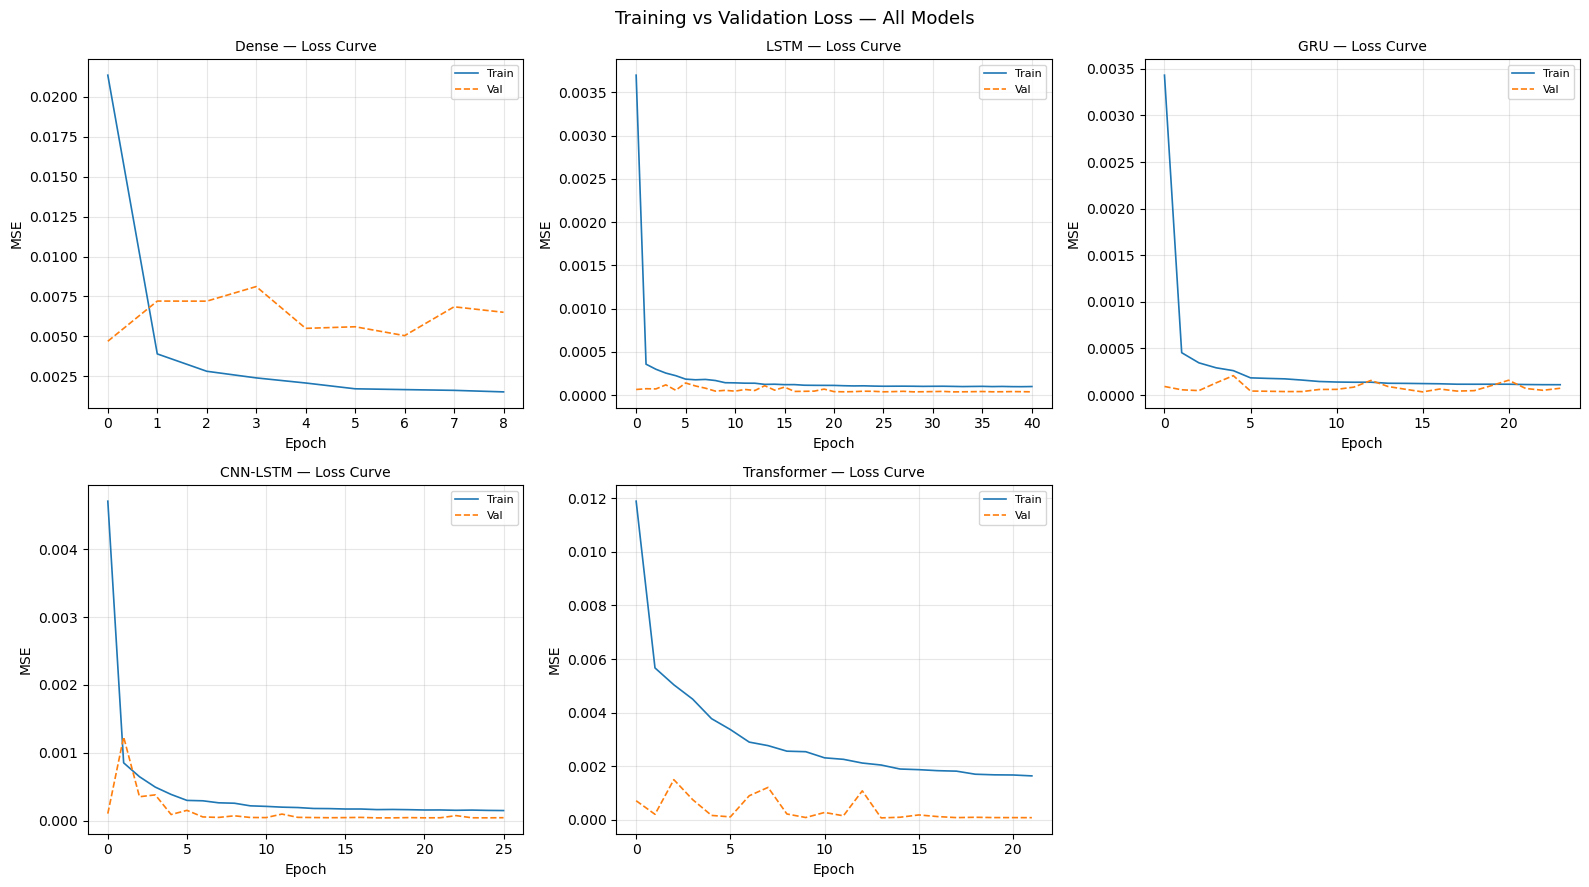

In [19]:
# 1. Training Loss Curves (all models) 
histories = {
    "Dense":       history_dense,
    "LSTM":        history_lstm,
    "GRU":         history_gru,
    "CNN-LSTM":    history_cnn_lstm,
    "Transformer": history_transformer,
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (name, hist) in zip(axes, histories.items()):
    ax.plot(hist.history["loss"],     label="Train", linewidth=1.2)
    ax.plot(hist.history["val_loss"], label="Val",   linewidth=1.2, linestyle="--")
    ax.set_title(f"{name} — Loss Curve", fontsize=10)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[5].set_visible(False)
plt.suptitle("Training vs Validation Loss — All Models", fontsize=13)
plt.tight_layout()
plt.savefig("partB_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()

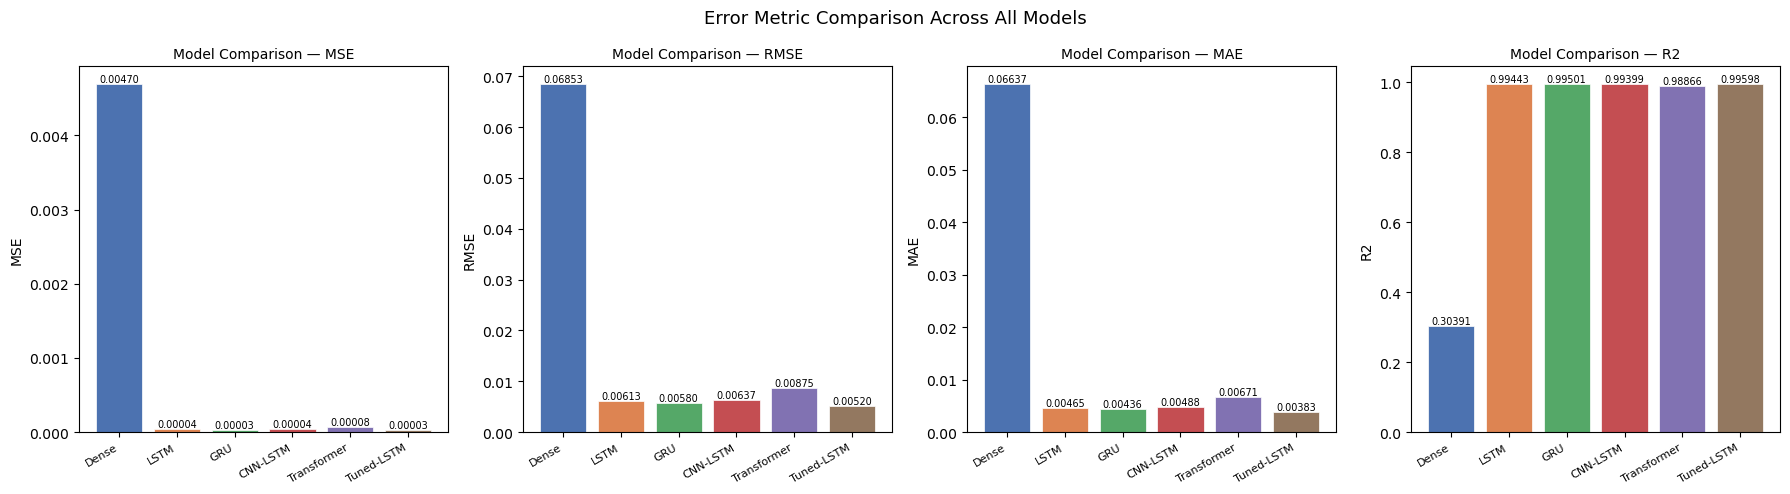

In [20]:
# 2. Metric Comparison Bar Charts 
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]

for ax, metric in zip(axes, ["MSE", "RMSE", "MAE", "R2"]):
    vals = metrics_df[metric].values
    bars = ax.bar(model_names, vals, color=colors, edgecolor="white", linewidth=0.5)
    ax.set_title(f"Model Comparison — {metric}", fontsize=10)
    ax.set_xticklabels(model_names, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel(metric)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f"{v:.5f}", ha="center", va="bottom", fontsize=7)

plt.suptitle("Error Metric Comparison Across All Models", fontsize=13)
plt.tight_layout()
plt.savefig("partB_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

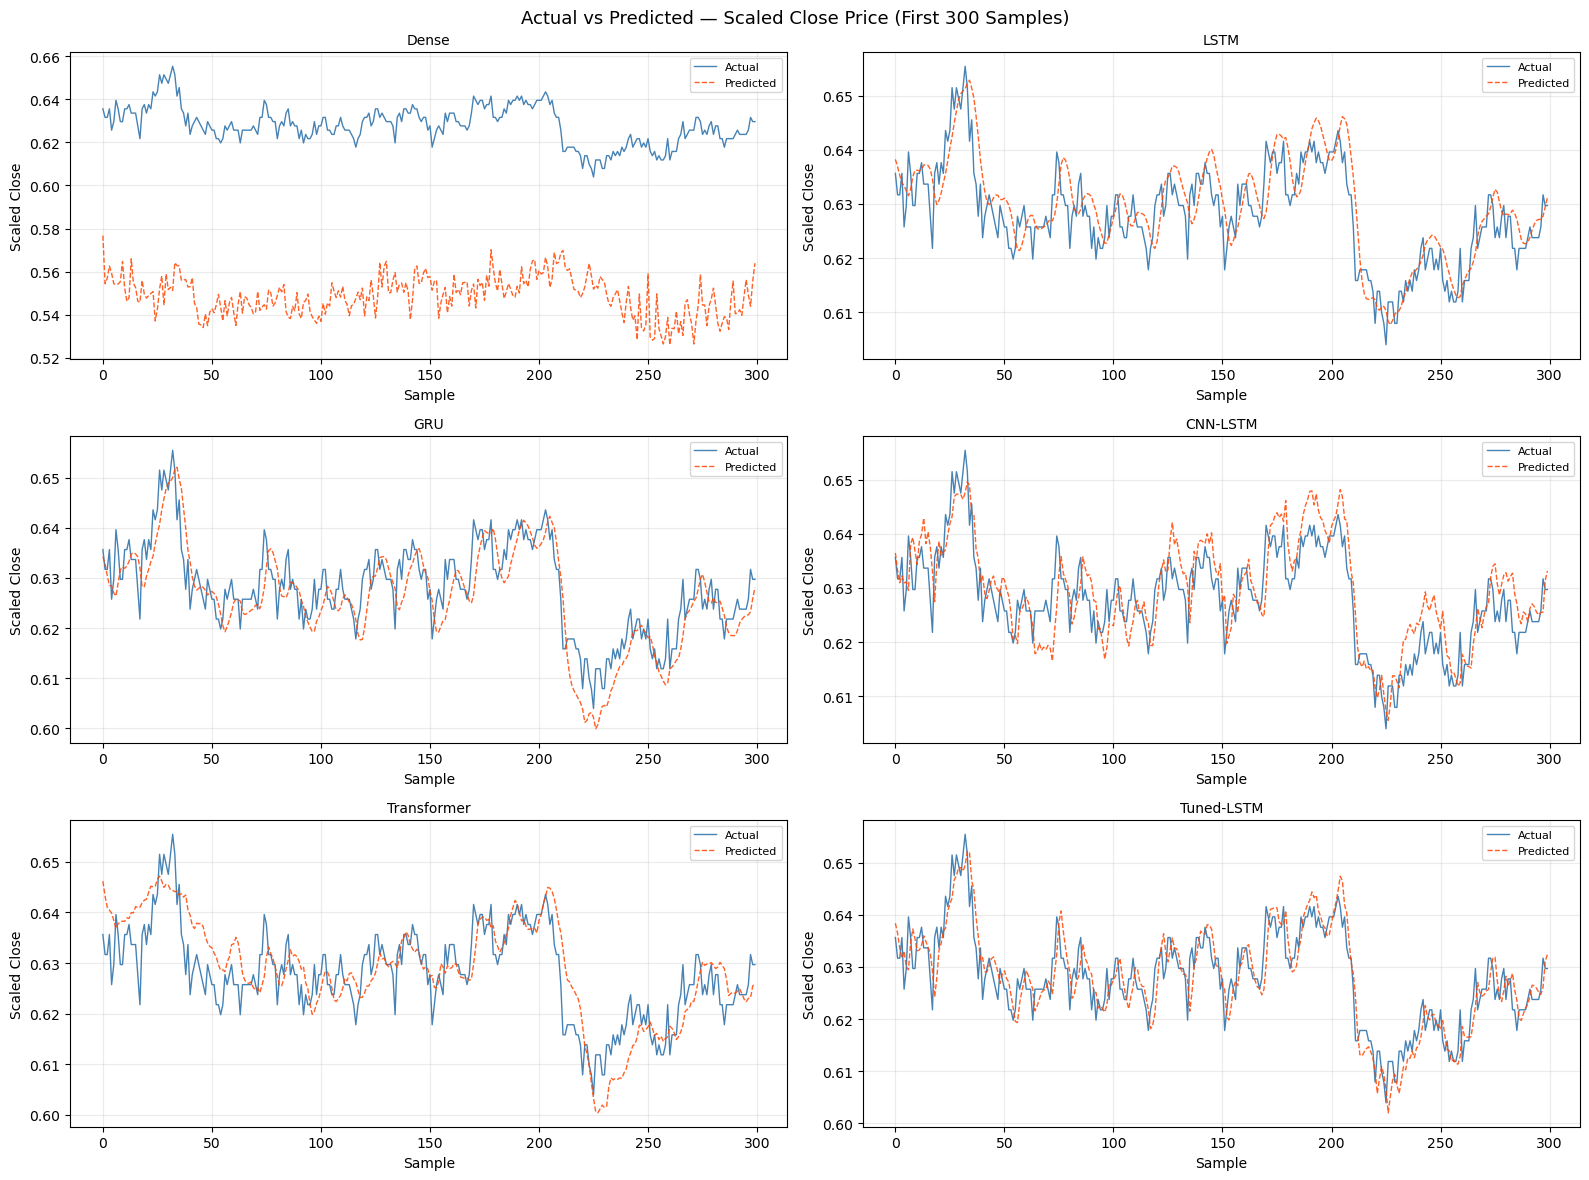

In [21]:
# 3. Actual vs Predicted (all models, first 300 pts) 
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, (name, pred) in zip(axes, zip(model_names, preds_list)):
    ax.plot(y_test[:300],  label="Actual",    linewidth=1, color="steelblue")
    ax.plot(pred[:300],    label="Predicted", linewidth=1, color="orangered",
            linestyle="--", alpha=0.85)
    ax.set_title(f"{name}", fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlabel("Sample")
    ax.set_ylabel("Scaled Close")
    ax.grid(True, alpha=0.25)

plt.suptitle("Actual vs Predicted — Scaled Close Price (First 300 Samples)", fontsize=13)
plt.tight_layout()
plt.savefig("partB_pred_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## More Advanced Visualisations (Real Scale + Residuals)

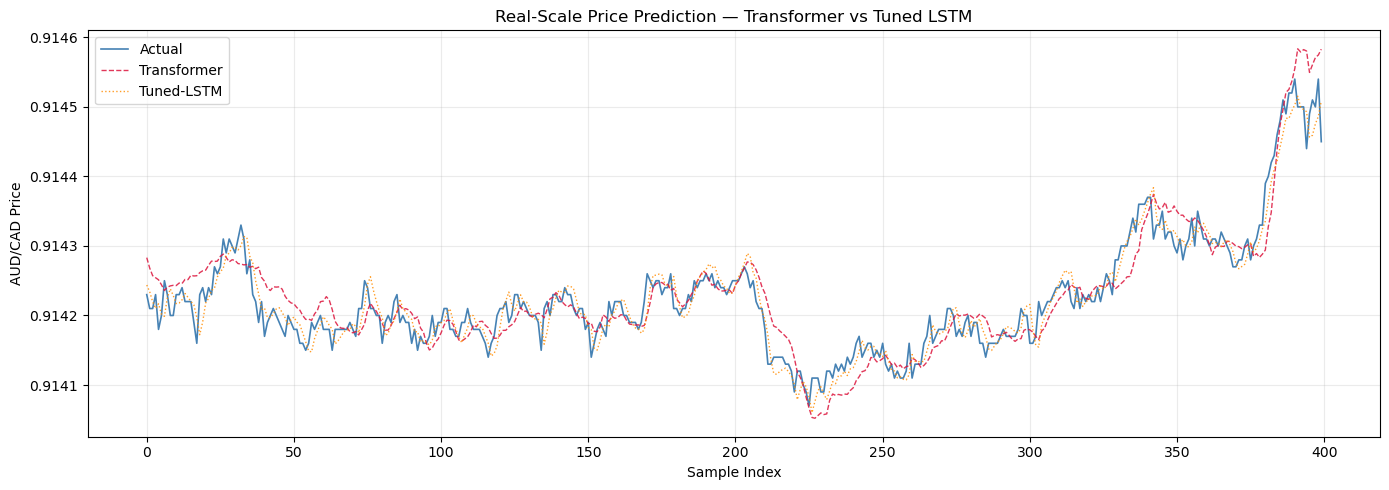

In [22]:
# Inverse-transform helper
def inverse_close(arr):
    temp = np.zeros((len(arr), n_features))
    temp[:, close_idx] = arr
    return scaler.inverse_transform(temp)[:, close_idx]

y_test_real      = inverse_close(y_test)
pred_transformer_real = inverse_close(pred_transformer)
pred_tuned_real  = inverse_close(pred_tuned)

# 4. Real-Scale: Transformer vs Tuned-LSTM
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_test_real[:400],          label="Actual",      linewidth=1.2, color="steelblue")
ax.plot(pred_transformer_real[:400], label="Transformer", linewidth=1,
        linestyle="--", color="crimson",    alpha=0.85)
ax.plot(pred_tuned_real[:400],       label="Tuned-LSTM",  linewidth=1,
        linestyle=":",  color="darkorange", alpha=0.85)
ax.set_title("Real-Scale Price Prediction — Transformer vs Tuned LSTM", fontsize=12)
ax.set_xlabel("Sample Index")
ax.set_ylabel("AUD/CAD Price")
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig("partB_realscale.png", dpi=150, bbox_inches="tight")
plt.show()

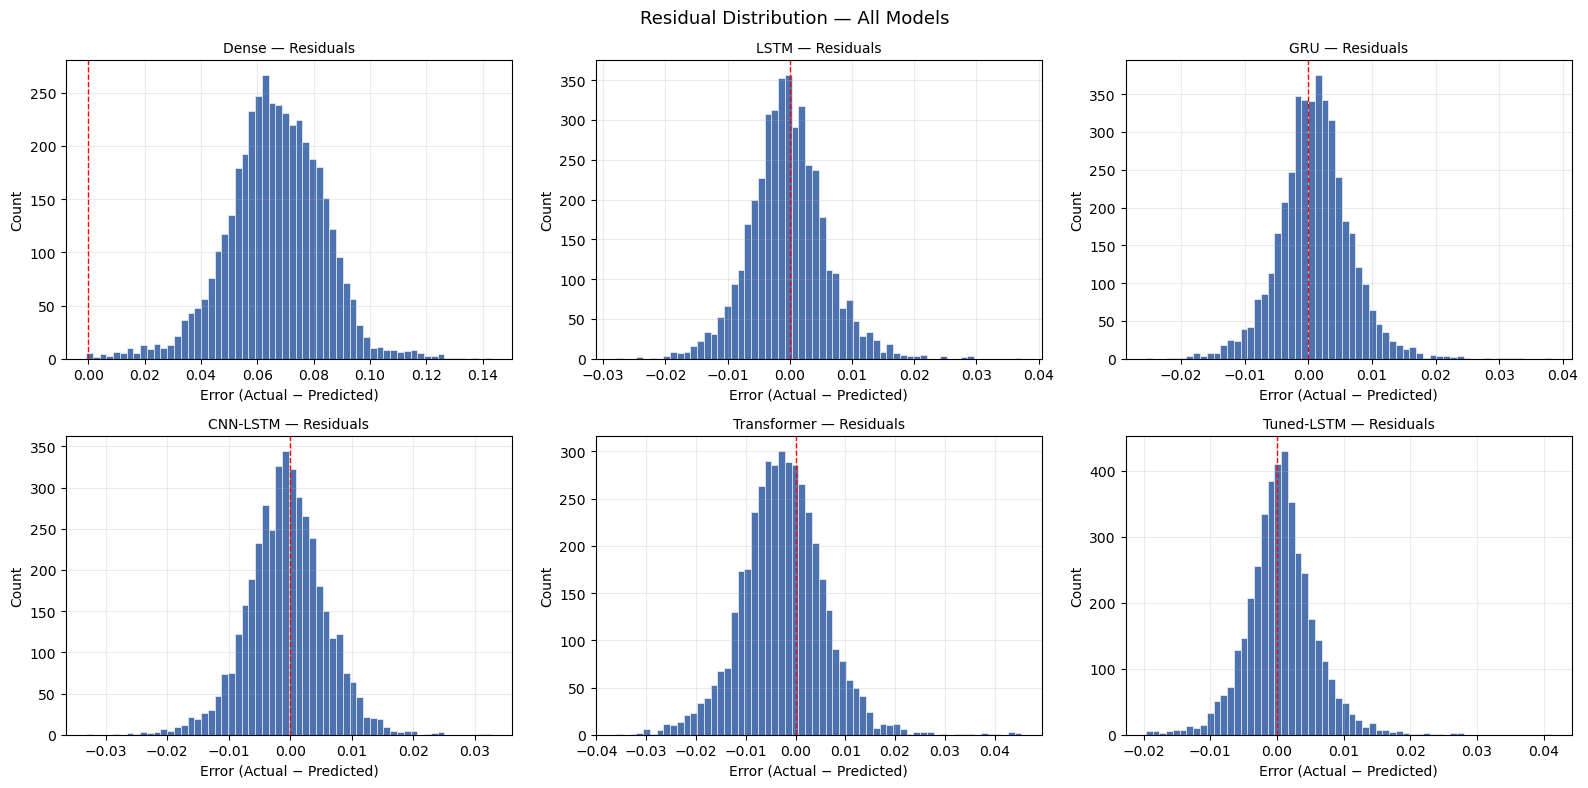

In [23]:
# 5. Residual Distribution per Model 
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, (name, pred) in zip(axes, zip(model_names, preds_list)):
    residuals = y_test - pred
    ax.hist(residuals, bins=60, color="#4C72B0", edgecolor="white", linewidth=0.4)
    ax.axvline(0, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"{name} — Residuals", fontsize=10)
    ax.set_xlabel("Error (Actual − Predicted)")
    ax.set_ylabel("Count")
    ax.grid(True, alpha=0.25)

plt.suptitle("Residual Distribution — All Models", fontsize=13)
plt.tight_layout()
plt.savefig("partB_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

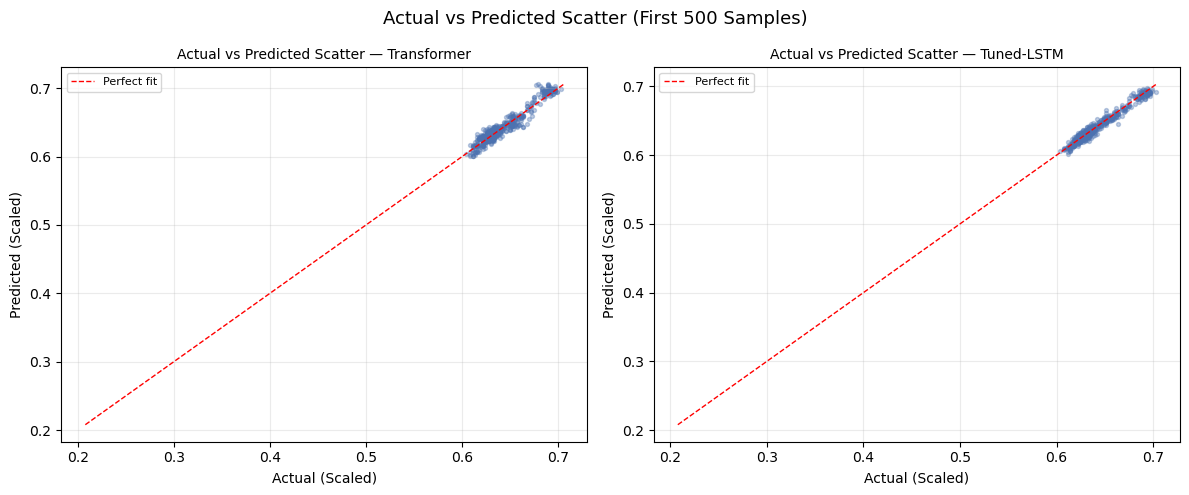

In [24]:
#  6. Scatter: Actual vs Predicted (best two models) 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, name, pred in zip(axes,
                           ["Transformer", "Tuned-LSTM"],
                           [pred_transformer, pred_tuned]):
    ax.scatter(y_test[:500], pred[:500], alpha=0.35, s=8, color="#4C72B0")
    mn = min(y_test.min(), pred.min())
    mx = max(y_test.max(), pred.max())
    ax.plot([mn, mx], [mn, mx], "r--", linewidth=1, label="Perfect fit")
    ax.set_title(f"Actual vs Predicted Scatter — {name}", fontsize=10)
    ax.set_xlabel("Actual (Scaled)")
    ax.set_ylabel("Predicted (Scaled)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)

plt.suptitle("Actual vs Predicted Scatter (First 500 Samples)", fontsize=13)
plt.tight_layout()
plt.savefig("partB_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

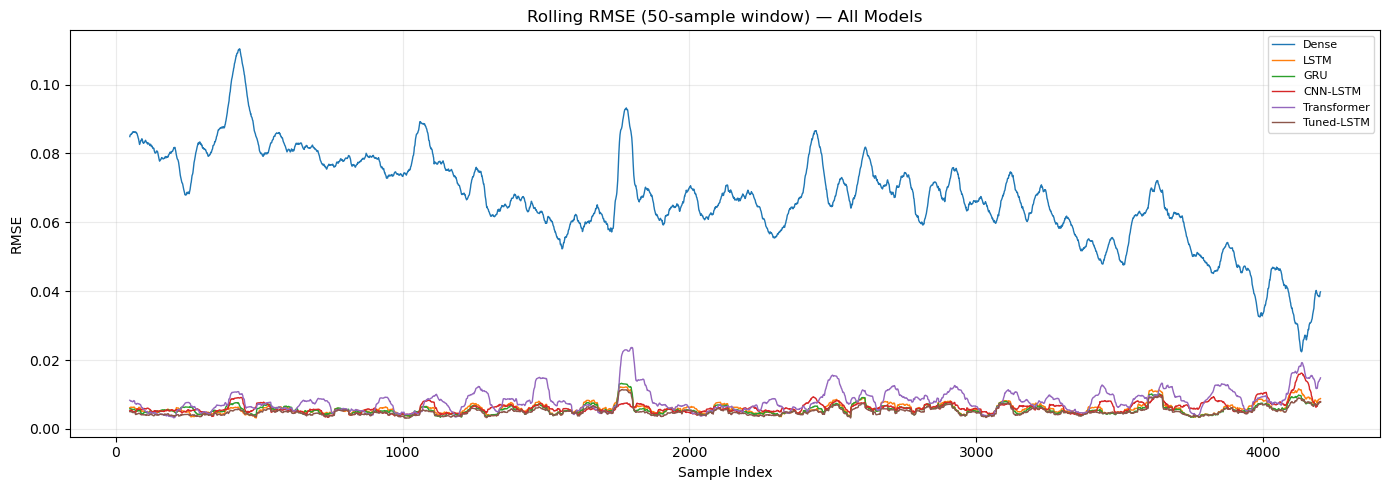

In [25]:
# 7. Rolling RMSE over test set 
window = 50
fig, ax = plt.subplots(figsize=(14, 5))

for name, pred in zip(model_names, preds_list):
    roll_rmse = pd.Series((y_test - pred)**2).rolling(window).mean().apply(np.sqrt)
    ax.plot(roll_rmse, label=name, linewidth=1)

ax.set_title(f"Rolling RMSE ({window}-sample window) — All Models", fontsize=12)
ax.set_xlabel("Sample Index")
ax.set_ylabel("RMSE")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig("partB_rolling_rmse.png", dpi=150, bbox_inches="tight")
plt.show()

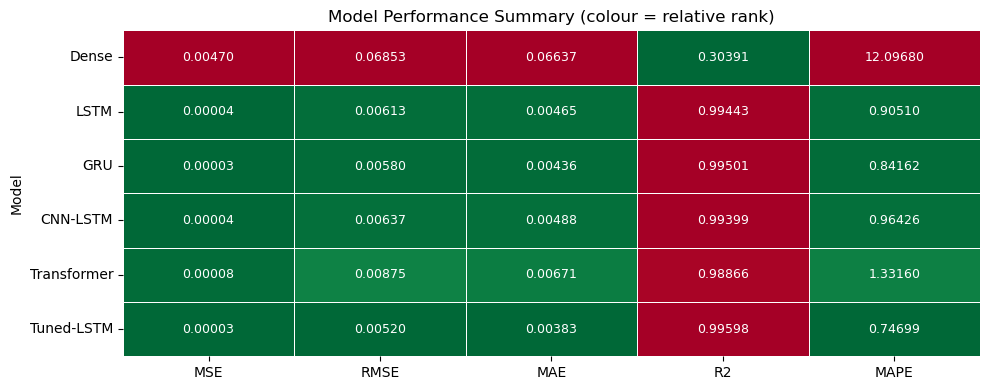

In [26]:
# 8. Heatmap: Metrics Summary
fig, ax = plt.subplots(figsize=(10, 4))
heat_data = metrics_df[["MSE","RMSE","MAE","R2","MAPE"]].copy()

# Normalise each column 0-1 for colour intensity
heat_norm = (heat_data - heat_data.min()) / (heat_data.max() - heat_data.min() + 1e-10)

sns.heatmap(heat_norm, annot=heat_data.round(5), fmt=".5f",
            cmap="RdYlGn_r", ax=ax, linewidths=0.5, cbar=False,
            annot_kws={"size": 9})
ax.set_title("Model Performance Summary (colour = relative rank)", fontsize=12)
plt.tight_layout()
plt.savefig("partB_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Save Models

In [27]:
import os

models_dir = "partB_models"
os.makedirs(models_dir, exist_ok=True)

model_dense.save(os.path.join(models_dir, "model_dense.keras"))
model_lstm.save(os.path.join(models_dir, "model_lstm.keras"))
model_gru.save(os.path.join(models_dir, "model_gru.keras"))
model_cnn_lstm.save(os.path.join(models_dir, "model_cnn_lstm.keras"))
model_transformer.save(os.path.join(models_dir, "model_transformer.keras"))
best_hp_model.save(os.path.join(models_dir, "model_tuned_lstm.keras"))

print(f"All models saved to: {models_dir}/")
print("\nSaved files:")
for f in sorted(os.listdir(models_dir)):
    size_kb = os.path.getsize(os.path.join(models_dir, f)) / 1024
    print(f"  {f:35s}  {size_kb:.1f} KB")

print("\nFinal metrics summary:")
print(metrics_df.round(6).to_string())

All models saved to: partB_models/

Saved files:
  model_cnn_lstm.keras                 611.0 KB
  model_dense.keras                    640.2 KB
  model_gru.keras                      1263.7 KB
  model_lstm.keras                     1656.0 KB
  model_transformer.keras              961.0 KB
  model_tuned_lstm.keras               1491.5 KB

Final metrics summary:
                  MSE      RMSE       MAE        R2       MAPE
Model                                                         
Dense        0.004696  0.068526  0.066371  0.303913  12.096799
LSTM         0.000038  0.006132  0.004654  0.994426   0.905097
GRU          0.000034  0.005802  0.004364  0.995009   0.841622
CNN-LSTM     0.000041  0.006367  0.004884  0.993991   0.964260
Transformer  0.000077  0.008748  0.006712  0.988657   1.331600
Tuned-LSTM   0.000027  0.005205  0.003835  0.995984   0.746994
